In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
from tqdm.auto import tqdm

from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    seed_everything,
    make_trajectories,
    postprocess_data,
)
from JacobianODE.fnn import loss_amplification
from JacobianODE.jacobians.data import embed_signal_torch

In [3]:
# Standard Lorenz config (data=dysts defaults to Lorenz, 32 trials, 12 periods, 100 pts/period)
cfg = load_config(overrides=[
    "data=dysts",
    # "data.postprocessing.obs_noise=0.05",
    "data.postprocessing.obs_noise=0.01",
    f"training.logger.save_dir={os.getcwd()}",
])
cfg = initialize_config(cfg)
seed_everything(cfg.data.flow.random_state + cfg.training.run_number)

eq, sol, dt = make_trajectories(cfg, verbose=True)
values_raw = sol["values"]  # shape (n_trials, n_timepoints, n_dims)
result = postprocess_data(cfg, values_raw)
values = result.values
print(f"Loaded Lorenz: {values.shape}, dt={dt:.4f}")
x = torch.from_numpy(values)[..., [0]]
print(f"Generate x: {x.shape}")

Loaded Lorenz: (32, 1200, 3), dt=0.0150
Generate x: torch.Size([32, 1200, 1])


In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
amplification_losses = {}
N_DELAYS_VALS = np.arange(1, 51)
INTERVAL_VALS = np.arange(1, 11)

iterator = tqdm(total=len(N_DELAYS_VALS) * len(INTERVAL_VALS))

for n_delays in N_DELAYS_VALS:
    for delay_interval in INTERVAL_VALS:
        x_embedded = embed_signal_torch(x, n_delays, delay_interval)
        x_data = x_embedded[..., :x.shape[-1]]

        loss = loss_amplification(x_embedded.to(device), x_data.to(device), max_T=10, n_neighbors=10,normalize=True)
        amplification_losses[(n_delays, delay_interval)] = loss.item()

        iterator.update(1)
iterator.close()

  0%|          | 0/500 [00:00<?, ?it/s]

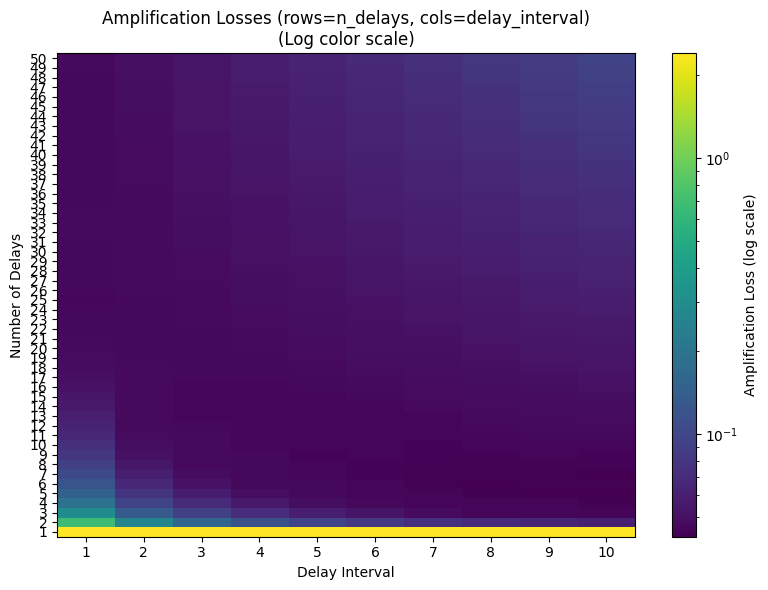

In [5]:
import numpy as np
from matplotlib.colors import LogNorm

# Convert the amplification_losses dict to a 2D array for plotting
n_delays_max = max(N_DELAYS_VALS)
interval_max = max(INTERVAL_VALS)
loss_matrix = np.zeros((n_delays_max, interval_max))
for (n_delays, delay_interval), loss in amplification_losses.items():
    loss_matrix[n_delays-1, delay_interval-1] = float(loss)

# To avoid issues with log scale, make sure there are no zeros (replace with a small value if necessary)
loss_matrix_for_log = np.where(loss_matrix > 0, loss_matrix, np.nanmin(loss_matrix[np.nonzero(loss_matrix)]) * 0.1)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    loss_matrix_for_log,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    norm=LogNorm(vmin=np.nanmin(loss_matrix_for_log), vmax=np.nanmax(loss_matrix_for_log))
)
cbar = plt.colorbar(im, ax=ax, label='Amplification Loss (log scale)')

# Set tick labels
ax.set_xticks(np.arange(interval_max))
ax.set_yticks(np.arange(n_delays_max))
ax.set_xticklabels(np.arange(1, interval_max + 1))
ax.set_yticklabels(np.arange(1, n_delays_max + 1))
ax.set_xlabel("Delay Interval")
ax.set_ylabel("Number of Delays")
ax.set_title("Amplification Losses (rows=n_delays, cols=delay_interval)\n(Log color scale)")
plt.tight_layout()
plt.show()

In [6]:
# Find the (n_delays, delay_interval) that gives the minimum amplification loss
best_params = min(amplification_losses, key=amplification_losses.get)
best_n_delays, best_delay_interval = best_params
best_loss = amplification_losses[best_params]

print(f"Best amplification loss: {best_loss:.5g} at n_delays={best_n_delays}, delay_interval={best_delay_interval}")

# Generate the embedding with these optimal parameters
best_x_embedded = embed_signal_torch(x, best_n_delays, best_delay_interval)

Best amplification loss: 0.042434 at n_delays=5, delay_interval=10


In [7]:
# Mean center embedded data
x_emb_flat = best_x_embedded.reshape(-1, best_x_embedded.shape[-1])
x_emb_flat_centered = x_emb_flat - torch.mean(x_emb_flat, dim=0, keepdim=True)

# Compute covariance matrix (torch, rowvar=False)
cov = torch.cov(x_emb_flat_centered.T)

# Eigendecomposition, torch returns eigvals in ascending order, so flip for descending
eigvals, eigvecs = torch.linalg.eigh(cov)
eigvals = eigvals.flip(dims=(0,))
eigvecs = eigvecs.flip(dims=(1,))

# Participation ratio (torch)
pr = (eigvals.sum())**2 / (eigvals**2).sum()
print(f"Participation Ratio: {pr.item():.3f}")

# Project mean-centered data onto principal components, most variance first
x_emb_pca = x_emb_flat_centered @ eigvecs

Participation Ratio: 1.394


In [8]:
# Mean center embedded data for values_raw
values_emb_flat = values_raw.reshape(-1, values_raw.shape[-1])
values_emb_flat = torch.from_numpy(values_emb_flat)
values_emb_flat_centered = values_emb_flat - torch.mean(values_emb_flat, dim=0, keepdim=True)

# Compute covariance matrix (torch, rowvar=False)
values_cov = torch.cov(values_emb_flat_centered.T)

# Eigendecomposition, torch returns eigvals in ascending order, so flip for descending
values_eigvals, values_eigvecs = torch.linalg.eigh(values_cov)
values_eigvals = values_eigvals.flip(dims=(0,))
values_eigvecs = values_eigvecs.flip(dims=(1,))

# Participation ratio (torch)
values_pr = (values_eigvals.sum())**2 / (values_eigvals**2).sum()
print(f"Participation Ratio (values_raw): {values_pr.item():.3f}")

# Project mean-centered data onto principal components, most variance first
values_emb_pca = values_emb_flat_centered @ values_eigvecs

Participation Ratio (values_raw): 1.668


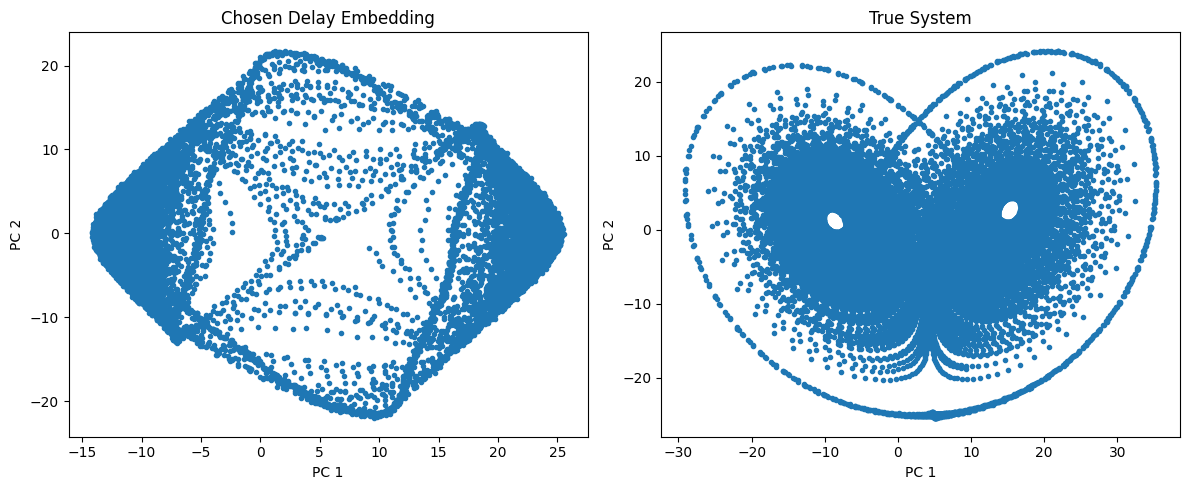

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(x_emb_pca[:, 0], x_emb_pca[:, 1], '.')
axs[0].set_title('Chosen Delay Embedding')
axs[0].set_xlabel('PC 1')
axs[0].set_ylabel('PC 2')

axs[1].plot(values_emb_pca[:, 0], values_emb_pca[:, 1], '.')
axs[1].set_title('True System')
axs[1].set_xlabel('PC 1')
axs[1].set_ylabel('PC 2')

plt.tight_layout()
plt.show()